## Metody obliczania pierwisatka kwadratowego
W tym opracowaniu skupię się na pokazaniu standardowego sposobu wyliczania pierwiastka kwadratowego z podanej liczby. W obecnych bibliotekach najpowszechnijesza jest metoda Newtona-Raphsona, która wykorzystuje własności stycnzych, o czym więcej dalej. Metoda Newtona-Raphsona jest wybierana ze względu na bardzo niewielką liczbę obliczeń potrzebą do wyznaczenia pierwiastka z sensowną precyzją. Dla większości liczb liczba iteracji nie przekroczy 10.




### Implementacja
Poniżej znajdują się implementacje funkcji liczących pierwiastek kwadratowy danej liczby z zadaną precyzją. 

In [160]:
import math
def newton_raphson(x, precision):
    if x < 0:
        raise ValueError("Nie można obliczyć pierwiastka z liczby < 0!")
    if x == 0:
        return 0
    
    approx = x / 2.0
    max_iterations = 10000
    i = 0
    while i < max_iterations:
        next_approx = 0.5 * (approx + x / approx)
        
        if abs(approx - next_approx) < precision:
            return (next_approx, ++i )
        i += 1
        approx = next_approx
        
    return (next_approx, max_iterations)


In [163]:
import math
x = 5
epsilon = 1e-4
newton = newton_raphson(x, epsilon)
math = math.sqrt(x)
diff = abs(newton[0] - math)
print(f'{newton[0]:.30f}')
print(f'{math:.30f}')
print(diff)

2.236067977915803695054819399957
2.236067977499789805051477742381
4.1601389000334166e-10


#### Limity systemu zmiennoprzecinkowego w komupterach
Pomimo, że podajnemy funkcji precyzję, z jaką chcemy otrzymany wynik, to ta metoda nie do końca pozwala rzeczywiście kontrolować dokładność. Wynika to z faktu działania samej metody, której wyniki są bardzo szybko zbieżne, przez co zmiany w liczbie dokładnych cyfr po przecinku zwięszka się bardzo szybko. W rezultacie zamiast otrzymać dokładnie podaną precyzję, w większości przypadków szybciej otrzymamy zero maszynowe przy obliczaniu różnicy, ze względu na faktu ograniczeń rezprezentacji liczb. Poniżej przykład.

In [166]:
import math
x = 5
epsilon = 0.1e-3
newton = newton_raphson(x, epsilon)
math = math.sqrt(x)
diff = abs(newton[0] - math)
print(f'{newton[0]:.30f}')
print(f'{math:.30f}')
print(diff)

2.236067977915803695054819399957
2.236067977499789805051477742381
4.1601389000334166e-10


Powyżej funkcja została wywołana z ustaloną precyzją jak 0.001. Jednak jak widać na przykładzie wcale nie otrzymaliśmy dokładności 3 cyfr po przecinku a zbliżyliśmy się do 10! W poniższym przykładzie prezentuję, jak wygląda nasz warunek zaprzestania obliczeń, ktorym jest różnica między wcześniejszym, a kolejnym oszacowaniem. Warto zauważyć, że różnica pierwszej i drugiej iteracji jest rzędu jednej cyfry dziesiętnej, a różnica między drugą i trzecią to aż 5, podobnie jak między 3 i 4, aż w 5 otrzymujemy 0.


In [172]:
import math
def newton_raphson_diff(x, precision):
    approx = x / 2.0
    max_iterations = 10000
    for i in range(0, max_iterations):
        next_approx = 0.5 * (approx + x / approx)
        diff = abs(approx - next_approx)
        print(diff)
        if diff < precision:
            return (next_approx, ++i )
        approx = next_approx        
    return (next_approx, max_iterations)

In [174]:
newton_raphson_diff(5, 0.1e-10)

0.25
0.01388888888888884
4.31331953074654e-05
4.1601389000334166e-10
0.0


(2.23606797749979, 4)

### Różnice w wynikach

Co ciekawe dla niektórych przypadków wyniki funkcji sqrt z math i ręcznie zaimplementowanej się różnią. Otóż algorytm biblioteki math oprócz surowej metody Newtona-Raphsona stosuje kilka zabiegów mających na celu zminimalizowanie błędu. Co więc biblioteka math a właściwie cmath robi lepiej?

#### 1. Normalizacja mantysy
Jeszcze przed rozpoczęciem iteracji wartość mantysy liczby jest sprowadzane do pewnego zakresu (zależne od implementacji i biblioteki) i odpowiednio koryguje się wykładnik, co pozwala zminimalizować zakres wielkości, w jakich pracuje przybliżanie, dzięki czemu zachowanie funkcji jest jednorodniejsze i wymusza mniej iteracji. Można powiedzieć, że mamy większy zapas na obliczenia.
    

#### 2.  Lepsze początkowe przybliżenie
W powyższym kodzie, który jest surowym algorytmem stosujący metodę Newtona-Raphsona bez dodatkowych optymalizacji początkowe przybiżenie jest obliczane jako $\frac{x}{2}$. Co może mieć sens dla niektórych wartości jak np. 2, dla którego $\sqrt{2} \approx 1.4142$, jednak nie jest zawsze dobrym roziwązaniem. Poniżej przykład dla liczby x = 77

#### 3. Inne
Oprócz podanych wyżej operacji optymalizuje się też same działania jak dodawanie i mnożenie np. są wykonywane jednocześnie, dzięki temu zaokrągamy raz w dwóch działaciach, zasiast każdorazowo. Na końcu, kiedy otrzymujemy już wynik jest dokonywana korelta.



In [81]:
x = 77
epsilon = 1e-20
newton = newton_raphson(x, epsilon)
math = math.sqrt(x)
diff = abs(newton - math)
print(newton)
print(math)
print(diff)

8.77496438739212
8.774964387392123
1.7763568394002505e-15


Różnica jest względnie niewielka, ale jednak jest. Bibliotek z C stosuje dokładniejsze przybliżenie na podstawie binarnej rezprezentacji liczby. Ciężko jest dokładnie ustalić w jaki sposób, ponieważ w kodzie zamiast jawnych algorytmów i roziwązań często można natrafić na odwołanie do funkcji sprzętowej. Jednak głowna idea sprowadza się do operacji na bitach liczby w reprezentacji zmiennoprzecinkowej. Z tego, co udało mi się znaleźć proces opiera się na dzieleniu wykładnika i mantysy, sprawdzeniu wartości, dodanie stałej i powrotnej normalizacji. Na tej podstawie jest ustalana początkowa wartość przybliżenia. Dla $x = 77 : przybliżenie = 8.8125.$ Co jest całkiem bliskie realnej wartości $\sqrt{77} \approx 8.774964$

### Podstawy matetatyczne i wyjaśnienie
##### Metoda Newtona-Raphsona
Algorytm stosujący tę metodę wykorzystuje funkcję kwadratową i własności stycznych. Przy obliczaniu pierwiastka z danej liczby a, takiej że a $\geq$ 0. Dla wartości a $\leq$ 0 po prostu zwaracamy, że taki pierwiastek nie istenieje (pomijamy liczby zespolone). Niech $f(x) = x^2 -c$, gdzie c jest liczbą, z której szukamy pierwiastka. Rozwiązujemy zwyczajne równanie kwadratowe. $ x^2 - c = 0$. Rozwiązaniem tego równania jest $x = \sqrt{c}$. 
    Szukając $\sqrt{c}$ korzystamy ze wzoru:
    $$
            x_{n+1} = x_n + \frac{f(x_n)}{f'(x_n)} \Leftrightarrow \frac{1}{2}\!\left(x_n + \frac{c}{x_n}\right)
    $$
Otrzymujmey więc ciąg, któego pierwszy element musimy ustalić jako gorsze lub lepsze przybliżenie pierwiastka szukanej liczby np. $x_0 = \frac{c}{2}$.Otrymany ciąg tak naprawdę jest roziwązniem równań dla stycznej w punkcie $(x_n; f(x_n))$ przyrównanej do 0.
Jeżeli funkcja 𝑓 ma pochodną w punkcie $x_n$, to równanie stycznej do wykresu funkcji f w punkcie $(x_n, f(x_n))$ dane jest wzorem:
    $$ y = f'(x_n)(x - x_n) + f(x_n)$$
W naszym przypadku:
    $$ y = 2*x_n(x - x_n) + x_n^2 + c$$
    $$y = x_n^2 - c + 2x_n x - 2x_n^2$$
Kolejny wyraz $x_{n+1}$ to roziwązanie równania:
$$0 = x_n^2 - c + 2x_n(x - x_n)$$
$$x_{n+1} = x_n - \frac{x_n^2 - c}{2x_n}$$
$$x_{n+1} = \frac{1}{2} *\frac{x_n + \tfrac{c}{x_n}}{2}$$
$$x_{n+1} = \frac{1}{2}\!\left(x_n + \frac{c}{x_n}\right)$$
Z każdym kolejnym krokiem otrzymujemy co raz dokładniejsze przybliżenie, przerywamy aż uzyskamy porządaną precyzję lub (rzadki przypadek) przekroczymy maksymalną liczbę iteracji. W części infomatycznej pokazałem, że przybliżenia z porządaną precyzją często nie otrzymamy ze względu na ograniczenia reprezentacji liczb zmienno przecinkowych.
Poniżej graficzna wizualizacja kolejnych iteracji algorytmu. W poniższym przykładzie funkcja f(x) nie jest przesunięta o szukaną stałą. Dlatego wartościami $x_{n+1}$ są rozwiązania równania styczna g(x) = 10. Pierwszy punkt styczności P = $(x_0; f(x_0))$ dla uproszczenia wyznaczamy poprzez obliczenie: $x_0 = \frac{c}{2}$. Oczywiście nie jest to dobre przybilżenie, ale do celów wizualizacji wystarczy. 


    

    






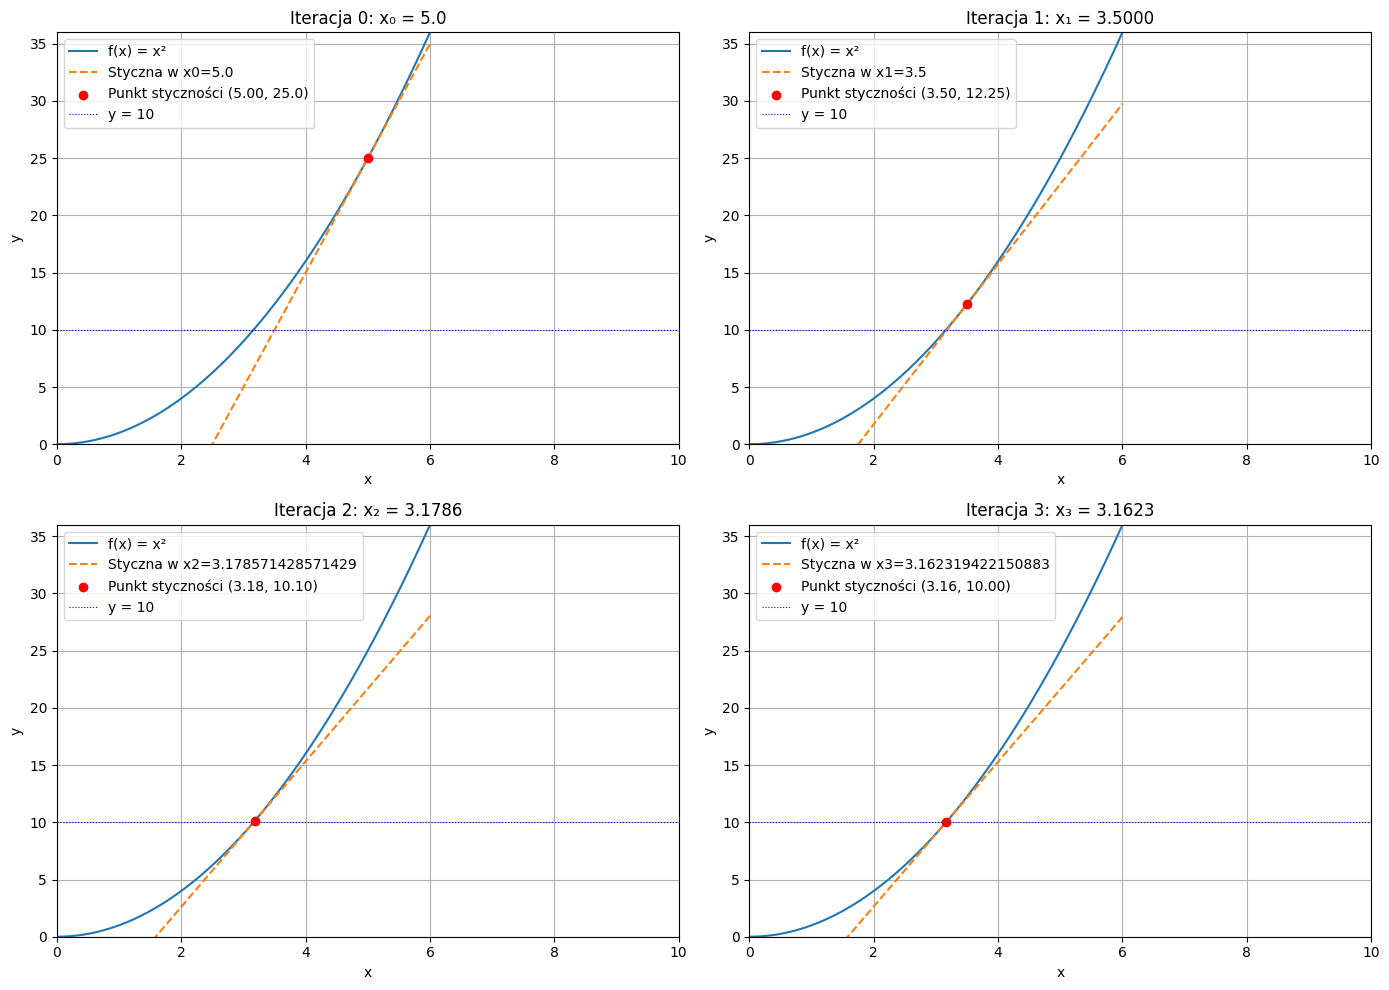

In [126]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2

def df(x):
    return 2 * x
c = 10.0
x0 = 5.0
x1 = 0.5 * (x0 + c / x0)
x2 = 0.5 * (x1 + c / x1)
x3 = 0.5 * (x2 + c / x2)

def styczna(xi, x):
    return 2 * xi * x - xi**2

# Zakres wartości x od 0 do 10
x = np.linspace(0, 6, 400)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()
y_min, y_max = 0, 36

axs[0].plot(x, f(x), label='f(x) = x²')
axs[0].plot(x, styczna(x0, x), '--', label=f'Styczna w x0={x0}')
axs[0].scatter([x0], [f(x0)], color='red', zorder=5, label=f'Punkt styczności ({x0:.2f}, {f(x0)})')
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].axhline(10, color='blue', linestyle=':', linewidth=0.8, label='y = 10')
axs[0].axvline(0, color='black', linewidth=0.5)
axs[0].set_xlim(0, 10)
axs[0].set_ylim(y_min, y_max)
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title(f'Iteracja 0: x₀ = {x0}')
axs[0].legend()
axs[0].grid(True)

# Iteracja 1: x1
axs[1].plot(x, f(x), label='f(x) = x²')
axs[1].plot(x, styczna(x1, x), '--', label=f'Styczna w x1={x1}')
axs[1].scatter([x1], [f(x1)], color='red', zorder=5, label=f'Punkt styczności ({x1:.2f}, {f(x1):.2f})')
axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].axhline(10, color='blue', linestyle=':', linewidth=0.8, label='y = 10')
axs[1].axvline(0, color='black', linewidth=0.5)
axs[1].set_xlim(0, 10)
axs[1].set_ylim(y_min, y_max)
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_title(f'Iteracja 1: x₁ = {x1:.4f}')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(x, f(x), label='f(x) = x²')
axs[2].plot(x, styczna(x2, x), '--', label=f'Styczna w x2={x2}')
axs[2].scatter([x2], [f(x2)], color='red', zorder=5, label=f'Punkt styczności ({x2:.2f}, {f(x2):.2f})')
axs[2].axhline(0, color='black', linewidth=0.5)
axs[2].axhline(10, color='blue', linestyle=':', linewidth=0.8, label='y = 10')
axs[2].axvline(0, color='black', linewidth=0.5)
axs[2].set_xlim(0, 10)
axs[2].set_ylim(y_min, y_max)
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')
axs[2].set_title(f'Iteracja 2: x₂ = {x2:.4f}')
axs[2].legend()
axs[2].grid(True)

axs[3].plot(x, f(x), label='f(x) = x²')
axs[3].plot(x, styczna(x3, x), '--', label=f'Styczna w x3={x3}')
axs[3].scatter([x3], [f(x3)], color='red', zorder=5, label=f'Punkt styczności ({x3:.2f}, {f(x3):.2f})')
axs[3].axhline(0, color='black', linewidth=0.5)
axs[3].axhline(10, color='blue', linestyle=':', linewidth=0.8, label='y = 10')
axs[3].axvline(0, color='black', linewidth=0.5)
axs[3].set_xlim(0, 10)
axs[3].set_ylim(y_min, y_max)
axs[3].set_xlabel('x')
axs[3].set_ylabel('y')
axs[3].set_title(f'Iteracja 3: x₃ = {x3:.4f}')
axs[3].legend()
axs[3].grid(True)

plt.tight_layout()
plt.show()


## Zastosowania
### Obliczanie odległości na płaszczyźnie

   Oczywistym przykładem jest liczenie odległości między dwoma punktami. ze wzoru $ d = \sqrt{(x_1-x_2)^2+(y_1-y_2)^2}$. Jest to
Dajmy na to w grze mutliplayer, gdzie gracze walczą ze sobą swoimi postaciami. Jedna z postaci ma umiejętność o pewnym zasięgu. więc po użyciu należy liczyć odległość, od punktu startowego tak, żeby przebyła ustaloną odległość. Jeśli była to umiejętność ofensywna wówczas należy też obliczyć, czy np. trafia wrogiego gracza. Niech model gracza będzie kołem na płaszczyźnie, wtedy musimy obliczyć odległość od środka koła i porównać z promieniem.

    
Jednak o ile w powyższym przykładzie dokładność oczywiście ma znacznie, to błędy rzędu dwudziestego miejsca po przecinku nie będą powodowały problemów, ponieważ taka różnica będzie nie zauważalna, jeśli nasze obiekty mają wielkość np. 100 jednostek. Dlacztego chciałem znaleźć przykład zastostowania, w którym duża dokładność obliczeń ma kluczowe znaczenie. Błędy będą się najbardziej uwidaczniały, jeśli z niedokładna wartość będzie wykorzystywana wielkrotnie do jakiegoś rodzaju obliczeń.
Weźmy przykład z fizyki, gdzie operowanie na bardzo małych wartościach jest normą.
W symulacjach molekularnych (MD) obliczanie odległości między atomami wymaga wielokrotnego wyznaczania $\sqrt{(\Delta x)^2 + (\Delta y)^2 + (\Delta z)^2}$, a mimo że błąd w pojedynczym wywołaniu może wynosić tylko około $10^{-15}$ w podwójnej precyzji, to przy milionach kroków czasowych niewielkie przybliżenie w normie atomowej przekłada się na błędy sił ($\propto r^{-7}$) i kumuluje się w kolejnych iteracjach, powodując już naczący błąd, który może prowadzić do błędów w obliczeniach, a co za tym idzie może prowadzić do błęddnych wniosków i zaburzać wyniki symulacji.





